# LLM Sokoban Agent 비교 실험

## tl;dr

- 저장된 `gemma4:26b` 실행은 동일한 3개 레벨 × 2개 seed 중 2/6 에피소드(33%)를 해결했다. 성공은 `tiny-push` 2회였다.
- BFS는 6/6, Random은 0/6을 해결했다.
- LLM은 총 88회 호출했고 30회 재시도했으며, Python 검증기가 막힌 행동 32회를 환경 실행 전에 거절했다.
- 이 수치는 아래 고정 설정으로 저장된 실행 결과이며, 모델이나 설정을 바꾸면 다시 실행해 갱신해야 한다.

## Context & Methods

상태 배열을 표준 Sokoban 문자 보드로 직렬화하고, 모델에는 `{"action":"UP"}` 형태의 JSON Schema 출력을 요구한다. Python Agent가 응답 형식과 현재 보드에서의 이동 가능 여부를 검증한 뒤 환경에 전달한다.

### Key Assumptions

- `.env`의 Ollama 서버와 모델이 실행 시점에 사용 가능하다.
- `temperature=0`과 episode seed를 모델 호출에 전달하지만, 런타임·모델 버전에 따라 완전한 결정성은 보장되지 않는다.
- `heldout-turn`은 제품 기본 레벨에 포함하지 않은 실험용 소형 레벨이다.
- 실행 시간은 로컬/원격 Ollama 상태의 영향을 받는다.

### 1. Load dependencies and fixed parameters

In [1]:
from dataclasses import asdict

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from sokoban_agent.agents import BFSAgent, LLMAgent, RandomAgent
from sokoban_agent.agents.llm import OllamaClient, OllamaSettings
from sokoban_agent.env import (
    DEFAULT_LEVELS,
    FixedLevelProvider,
    SokobanEnv,
    parse_level,
)
from sokoban_agent.evaluation import (
    run_benchmark,
    summarize_by_agent,
)

LEVEL_IDS = ['tiny-push', 'tiny-walk', 'heldout-turn']
SEEDS = [0, 1]
MAX_STEPS = 15
MAX_ATTEMPTS = 3

settings = OllamaSettings.from_env()
experiment_config = {
    'model': settings.model,
    'temperature': settings.temperature,
    'level_ids': LEVEL_IDS,
    'seeds': SEEDS,
    'max_steps': MAX_STEPS,
    'max_attempts': MAX_ATTEMPTS,
}
experiment_config

Matplotlib is building the font cache; this may take a moment.


{'model': 'gemma4:26b',
 'temperature': 0.0,
 'level_ids': ['tiny-push', 'tiny-walk', 'heldout-turn'],
 'seeds': [0, 1],
 'max_steps': 15,
 'max_attempts': 3}

## Data

### 2. Build the fixed and held-out level cohort

In [2]:
heldout_level = parse_level(
    'heldout-turn',
    [
        '#####',
        '#.  #',
        '# $ #',
        '#  @#',
        '#####',
    ],
)
level_provider = FixedLevelProvider(
    [
        DEFAULT_LEVELS.get('tiny-push'),
        DEFAULT_LEVELS.get('tiny-walk'),
        heldout_level,
    ]
)
LEVEL_IDS

['tiny-push', 'tiny-walk', 'heldout-turn']

### 3. Run identical cases

In [3]:
client = OllamaClient(settings)
agents = [
    RandomAgent(),
    BFSAgent(),
    LLMAgent(
        client,
        model_name=settings.model,
        max_attempts=MAX_ATTEMPTS,
    ),
]
env = SokobanEnv(
    level_provider=level_provider,
    max_steps=MAX_STEPS,
)
try:
    results = run_benchmark(
        env,
        agents,
        level_ids=LEVEL_IDS,
        seeds=SEEDS,
    )
finally:
    env.close()

results_df = pd.DataFrame.from_records(
    asdict(result) for result in results
)
results_df

,agent_name,level_id,seed,success,deadlock,truncated,action_count,invalid_moves,total_reward,elapsed_seconds,failure_reason,llm_calls,llm_retries,llm_client_errors,llm_format_errors,llm_invalid_actions,llm_elapsed_seconds
0,random,tiny-push,0,False,False,True,15,6,-1.5,0.000809,NaN,0,0,0,0,0,0.000000
1,random,tiny-push,1,False,False,True,15,4,-1.5,0.000139,NaN,0,0,0,0,0,0.000000
2,random,tiny-walk,0,False,False,True,15,7,-1.5,0.000106,NaN,0,0,0,0,0,0.000000
3,random,tiny-walk,1,False,False,True,15,5,-1.5,0.000095,NaN,0,0,0,0,0,0.000000
4,random,heldout-turn,0,False,False,True,15,7,-1.5,0.000097,NaN,0,0,0,0,0,0.000000
5,random,heldout-turn,1,False,False,True,15,5,-1.5,0.000093,NaN,0,0,0,0,0,0.000000
6,bfs,tiny-push,0,True,False,False,1,0,10.9,0.000053,NaN,0,0,0,0,0,0.000000
7,bfs,tiny-push,1,True,False,False,1,0,10.9,0.000027,NaN,0,0,0,0,0,0.000000
8,bfs,tiny-walk,0,True,False,False,5,0,10.5,0.000122,NaN,0,0,0,0,0,0.000000
9,bfs,tiny-walk,1,True,False,False,5,0,10.5,0.000118,NaN,0,0,0,0,0,0.000000


## Results

### 4. Compare success, efficiency, recovery, and latency

In [4]:
summary_df = pd.DataFrame.from_records(
    asdict(summary) for summary in summarize_by_agent(results)
).set_index('agent_name')
summary_columns = [
    'episode_count',
    'success_count',
    'success_rate',
    'mean_actions',
    'mean_actions_on_success',
    'mean_elapsed_seconds',
    'total_llm_calls',
    'total_llm_retries',
    'total_llm_format_errors',
    'total_llm_invalid_actions',
    'mean_llm_elapsed_seconds',
]
summary_df[summary_columns]

,episode_count,success_count,success_rate,mean_actions,mean_actions_on_success,mean_elapsed_seconds,total_llm_calls,total_llm_retries,total_llm_format_errors,total_llm_invalid_actions,mean_llm_elapsed_seconds
agent_name,,,,,,,,,,,
random,6,0,0.000000,15.000000,NaN,0.000223,0,0,0,0,0.000000
bfs,6,6,1.000000,3.666667,3.666667,0.000091,0,0,0,0,0.000000
llm:gemma4:26b,6,2,0.333333,9.333333,1.000000,11.680655,88,30,0,32,11.677589


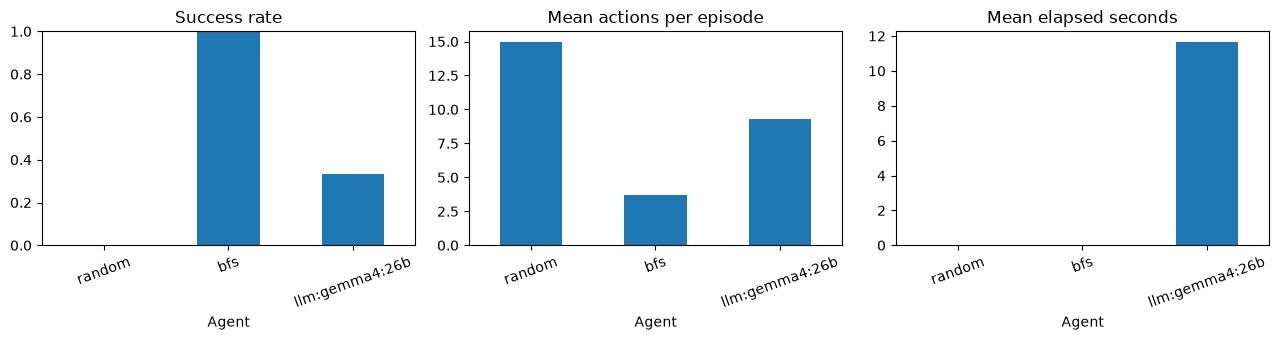

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
summary_df['success_rate'].plot.bar(
    ax=axes[0], ylim=(0, 1), title='Success rate'
)
summary_df['mean_actions'].plot.bar(
    ax=axes[1], title='Mean actions per episode'
)
summary_df['mean_elapsed_seconds'].plot.bar(
    ax=axes[2], title='Mean elapsed seconds'
)
for axis in axes:
    axis.set_xlabel('Agent')
    axis.tick_params(axis='x', rotation=20)
fig.tight_layout()
plt.show()

### 5. Inspect LLM failures by level and seed

In [6]:
llm_name = f'llm:{settings.model}'
llm_columns = [
    'level_id',
    'seed',
    'success',
    'deadlock',
    'truncated',
    'action_count',
    'llm_calls',
    'llm_retries',
    'llm_client_errors',
    'llm_format_errors',
    'llm_invalid_actions',
    'llm_elapsed_seconds',
    'failure_reason',
]
llm_results_df = results_df[
    results_df['agent_name'] == llm_name
][llm_columns]
llm_results_df

,level_id,seed,success,deadlock,truncated,action_count,llm_calls,llm_retries,llm_client_errors,llm_format_errors,llm_invalid_actions,llm_elapsed_seconds,failure_reason
12,tiny-push,0,True,False,False,1,1,0,0,0,0,1.438635,NaN
13,tiny-push,1,True,False,False,1,1,0,0,0,0,1.468781,NaN
14,tiny-walk,0,False,False,True,15,23,8,0,0,8,18.867400,NaN
15,tiny-walk,1,False,False,True,15,23,8,0,0,8,17.561112,NaN
16,heldout-turn,0,False,False,False,12,20,7,0,0,8,15.247455,LLM failed to return a legal action after 3 at...
17,heldout-turn,1,False,False,False,12,20,7,0,0,8,15.482151,LLM failed to return a legal action after 3 at...


### 6. Validate the comparison cohort

In [7]:
case_sets = {
    agent_name: set(
        zip(group['level_id'], group['seed'], strict=True)
    )
    for agent_name, group in results_df.groupby('agent_name')
}
expected_cases = set(
    (level_id, seed)
    for level_id in LEVEL_IDS
    for seed in SEEDS
)
assert all(cases == expected_cases for cases in case_sets.values())
assert summary_df.loc['bfs', 'success_rate'] == 1.0
assert summary_df.loc[llm_name, 'total_llm_client_errors'] == 0
{name: len(cases) for name, cases in case_sets.items()}

{'bfs': 6, 'llm:gemma4:26b': 6, 'random': 6}

## Takeaways

In [8]:
llm_summary = summary_df.loc[llm_name]
bfs_summary = summary_df.loc['bfs']
solved_levels = llm_results_df.loc[
    llm_results_df['success'], 'level_id'
].value_counts().to_dict()
display(Markdown(
    f'- LLM은 {int(llm_summary.success_count)}/'
    f'{int(llm_summary.episode_count)} 에피소드를 해결했다 '
    f'({llm_summary.success_rate:.0%}).\n'
    f'- BFS는 같은 cohort에서 '
    f'{bfs_summary.success_rate:.0%} 성공했다.\n'
    f'- LLM의 총 호출은 {int(llm_summary.total_llm_calls)}회, '
    f'재시도는 {int(llm_summary.total_llm_retries)}회, '
    f'막힌 행동 거절은 '
    f'{int(llm_summary.total_llm_invalid_actions)}회였다.\n'
    f'- 성공 레벨별 횟수: `{solved_levels}`. 이 결과는 소형 '
    '3개 레벨의 탐색 실험이며 전체 Boxoban 성능을 대표하지 않는다.'
))

- LLM은 2/6 에피소드를 해결했다 (33%).
- BFS는 같은 cohort에서 100% 성공했다.
- LLM의 총 호출은 88회, 재시도는 30회, 막힌 행동 거절은 32회였다.
- 성공 레벨별 횟수: `{'tiny-push': 2}`. 이 결과는 소형 3개 레벨의 탐색 실험이며 전체 Boxoban 성능을 대표하지 않는다.